In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [27]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalizador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
dt = DecisionTreeClassifier(
    max_depth=10, 
    criterion='entropy', 
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report — Decision Tree:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9805194805194806

Classification Report — Decision Tree:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       150
           1       0.98      0.98      0.98       158

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308



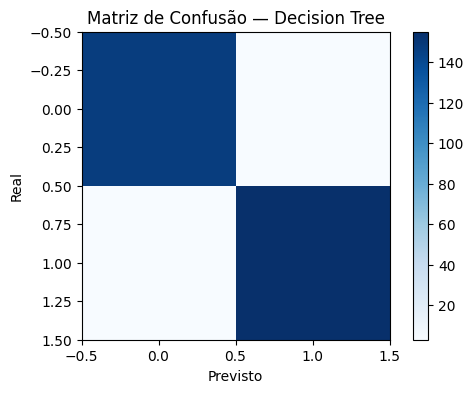

In [29]:
plt.figure(figsize=(6,4))
plt.title("Matriz de Confusão — Decision Tree")
plt.imshow(confusion_matrix(y_test, y_pred_dt), cmap="Blues")
plt.colorbar()
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [30]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report — KNN:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9058441558441559

Classification Report — KNN:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       150
           1       0.90      0.92      0.91       158

    accuracy                           0.91       308
   macro avg       0.91      0.91      0.91       308
weighted avg       0.91      0.91      0.91       308



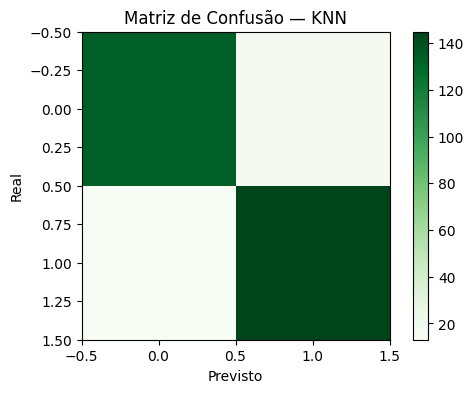

In [31]:
plt.figure(figsize=(6,4))
plt.title("Matriz de Confusão — KNN")
plt.imshow(confusion_matrix(y_test, y_pred_knn), cmap="Greens")
plt.colorbar()
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [32]:
dt2 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt2.fit(X_train, y_train)
y_pred_dt2 = dt2.predict(X_test)

print("DT (depth=10) Accuracy:", accuracy_score(y_test, y_pred_dt2))

DT (depth=10) Accuracy: 0.9805194805194806
